In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
CAMVID_CLASSES = [
    "Sky", "Building", "Pole", "Road", "Pavement",
    "Tree", "SignSymbol", "Fence", "Car",
    "Pedestrian", "Bicyclist"
]


In [4]:
# Standard CamVid 12-class colors (RGB)
class_colors = [
    [128, 128, 128], [128, 0, 0], [192, 192, 128], [128, 64, 128],
    [0, 0, 192], [128, 128, 0], [192, 128, 128], [64, 64, 128],
    [64, 0, 128], [64, 64, 0], [0, 128, 192], [0, 0, 0]
]

In [5]:
def rgb_to_mask(rgb_mask):
    """Efficiently converts RGB mask to class IDs using broadcasting."""
    mask = np.zeros((rgb_mask.shape[0], rgb_mask.shape[1]), dtype=np.int64)
    for i, color in enumerate(class_colors):
        # Find all pixels matching this RGB color
        match = np.all(rgb_mask == color, axis=-1)
        mask[match] = i
    return mask

In [6]:
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/CamVid'

In [ ]:
class CamVidDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        # List and sort files to ensure they match
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg'))])
        self.masks = sorted([f for f in os.listdir(mask_dir) if f.endswith(('.png', '.jpg'))])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask_rgb = np.array(Image.open(mask_path).convert("RGB"))

        # Convert RGB to ID
        mask_id = rgb_to_mask(mask_rgb)
        mask_pil = Image.fromarray(mask_id.astype('uint8'))

        if self.transform:
            image = self.transform(image)

        # Resizing to 360x480 (Width x Height order for PIL resize is (480, 360))
        # Use NEAREST for mask to avoid creating fake class IDs
        mask_pil = mask_pil.resize((480, 360), resample=Image.NEAREST)
        mask_tensor = torch.from_numpy(np.array(mask_pil)).long()

        return image, mask_tensor

# Normalization using ImageNet stats
transform = T.Compose([
    T.Resize((360, 480)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


print(f"Successfully linked Drive. Found {len(train_ds)} training images.")

Successfully linked Drive. Found 369 training images.


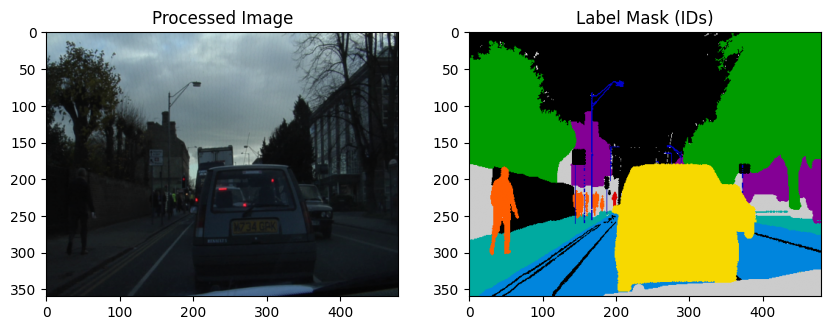

In [8]:
def visualize_check(dataset, index=0):
    img, mask = dataset[index]

    # Un-normalize image for viewing
    img_view = img.permute(1, 2, 0).numpy()
    img_view = img_view * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_view = np.clip(img_view, 0, 1)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_view)
    plt.title("Processed Image")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='nipy_spectral')
    plt.title("Label Mask (IDs)")
    plt.show()

visualize_check(train_ds)

In [9]:

train_ds = CamVidDataset(
    os.path.join(DATA_PATH, 'train/images'),
    os.path.join(DATA_PATH, 'train/labels'),
    transform=transform
)

val_ds = CamVidDataset(
    os.path.join(DATA_PATH, 'val/images'),
    os.path.join(DATA_PATH, 'val/labels'),
    transform=transform
)

test_ds = CamVidDataset(
    os.path.join(DATA_PATH, 'test/images'),
    os.path.join(DATA_PATH, 'test/labels'),
    transform=transform
)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, drop_last=False)


In [10]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks')

In [11]:
from models import BiSeNetV2_Improved

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Initialize Improved Model 
model_imp = BiSeNetV2_Improved(num_classes=12).to(device)

# DIFFERENT OPTIMIZER: AdamW 
# AdamW often performs better than SGD on smaller datasets like CamVid
optimizer_imp = torch.optim.AdamW(model_imp.parameters(), lr=0.001, weight_decay=0.01)

# DIFFERENT LOSS: Label Smoothing 
# Label smoothing helps the model generalize better by not being "too sure" about labels
criterion_imp = nn.CrossEntropyLoss()

epochs = 15
history_imp = {'train_loss': [], 'val_miou': []}

In [13]:
def get_miou(preds, labels, num_classes=12):
    preds = torch.argmax(preds, dim=1)
    ious = []
    for c in range(num_classes):
        intersection = ((preds == c) & (labels == c)).sum().item()
        union = ((preds == c) | (labels == c)).sum().item()
        if union == 0:
            ious.append(float('nan')) # Ignore classes not in the image
        else:
            ious.append(intersection / union)
    return np.nanmean(ious)

In [14]:
print("Starting IMPROVED training...")

for epoch in range(epochs):
    model_imp.train()
    epoch_loss = 0
    num_classes = 12

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer_imp.zero_grad()
        outputs = model_imp(images)
        loss = criterion_imp(outputs, masks)
        loss.backward()
        optimizer_imp.step()

        epoch_loss += loss.item()

    # Validation
    model_imp.eval()
    val_miou = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model_imp(images)
            val_miou += get_miou(preds, masks, num_classes)

    avg_loss = epoch_loss / len(train_loader)
    avg_miou = val_miou / len(val_loader)

    history_imp['train_loss'].append(avg_loss)
    history_imp['val_miou'].append(avg_miou)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f} - mIoU: {avg_miou:.4f}")


Starting IMPROVED training...
Epoch [1/15] - Loss: 1.3078 - mIoU: 0.1657
Epoch [2/15] - Loss: 1.0091 - mIoU: 0.2047
Epoch [3/15] - Loss: 0.9602 - mIoU: 0.2171
Epoch [4/15] - Loss: 0.9135 - mIoU: 0.2328
Epoch [5/15] - Loss: 0.8763 - mIoU: 0.2342
Epoch [6/15] - Loss: 0.8511 - mIoU: 0.2390
Epoch [7/15] - Loss: 0.8220 - mIoU: 0.2345
Epoch [8/15] - Loss: 0.8182 - mIoU: 0.2467
Epoch [9/15] - Loss: 0.7884 - mIoU: 0.2502
Epoch [10/15] - Loss: 0.7733 - mIoU: 0.2760
Epoch [11/15] - Loss: 0.7679 - mIoU: 0.2766
Epoch [12/15] - Loss: 0.7508 - mIoU: 0.2642
Epoch [13/15] - Loss: 0.7284 - mIoU: 0.2737
Epoch [14/15] - Loss: 0.7195 - mIoU: 0.2742
Epoch [15/15] - Loss: 0.7158 - mIoU: 0.2735


In [15]:
torch.save(
    model_imp.state_dict(),
    '/content/drive/MyDrive/bisenet_v2_improved.pth'
)

print("Improved model saved.")


Improved model saved.


In [20]:
from models import BiSeNetV2_Baseline, BiSeNetV2_Improved
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load baseline
model_base = BiSeNetV2_Baseline(num_classes=12).to(device)
model_base.load_state_dict(torch.load('/content/drive/MyDrive/bisenet_v2_baseline.pth', map_location=device))
model_base.eval()

# Load improved
model_imp = BiSeNetV2_Improved(num_classes=12).to(device)
model_imp.load_state_dict(torch.load('/content/drive/MyDrive/bisenet_v2_improved.pth', map_location=device))
model_imp.eval()

print("Both models loaded successfully")


Both models loaded successfully


In [ ]:
# Visualize the baseline and improved result for comparison
def visualize_baseline_vs_improved(
    model_base, model_imp, dataset, device, num_samples=3
):
    indices = random.sample(range(len(dataset)), num_samples)
    plt.figure(figsize=(20, 5 * num_samples))

    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        img_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            pred_base = torch.argmax(model_base(img_tensor), dim=1).squeeze(0).cpu().numpy()
            pred_imp  = torch.argmax(model_imp(img_tensor), dim=1).squeeze(0).cpu().numpy()

        # Un-normalize image
        img = image.permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        plt.subplot(num_samples, 4, i*4 + 1)
        plt.imshow(img)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(num_samples, 4, i*4 + 2)
        plt.imshow(mask, cmap="nipy_spectral")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_samples, 4, i*4 + 3)
        plt.imshow(pred_base, cmap="nipy_spectral")
        plt.title("Baseline Prediction")
        plt.axis("off")

        plt.subplot(num_samples, 4, i*4 + 4)
        plt.imshow(pred_imp, cmap="nipy_spectral")
        plt.title("Improved Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


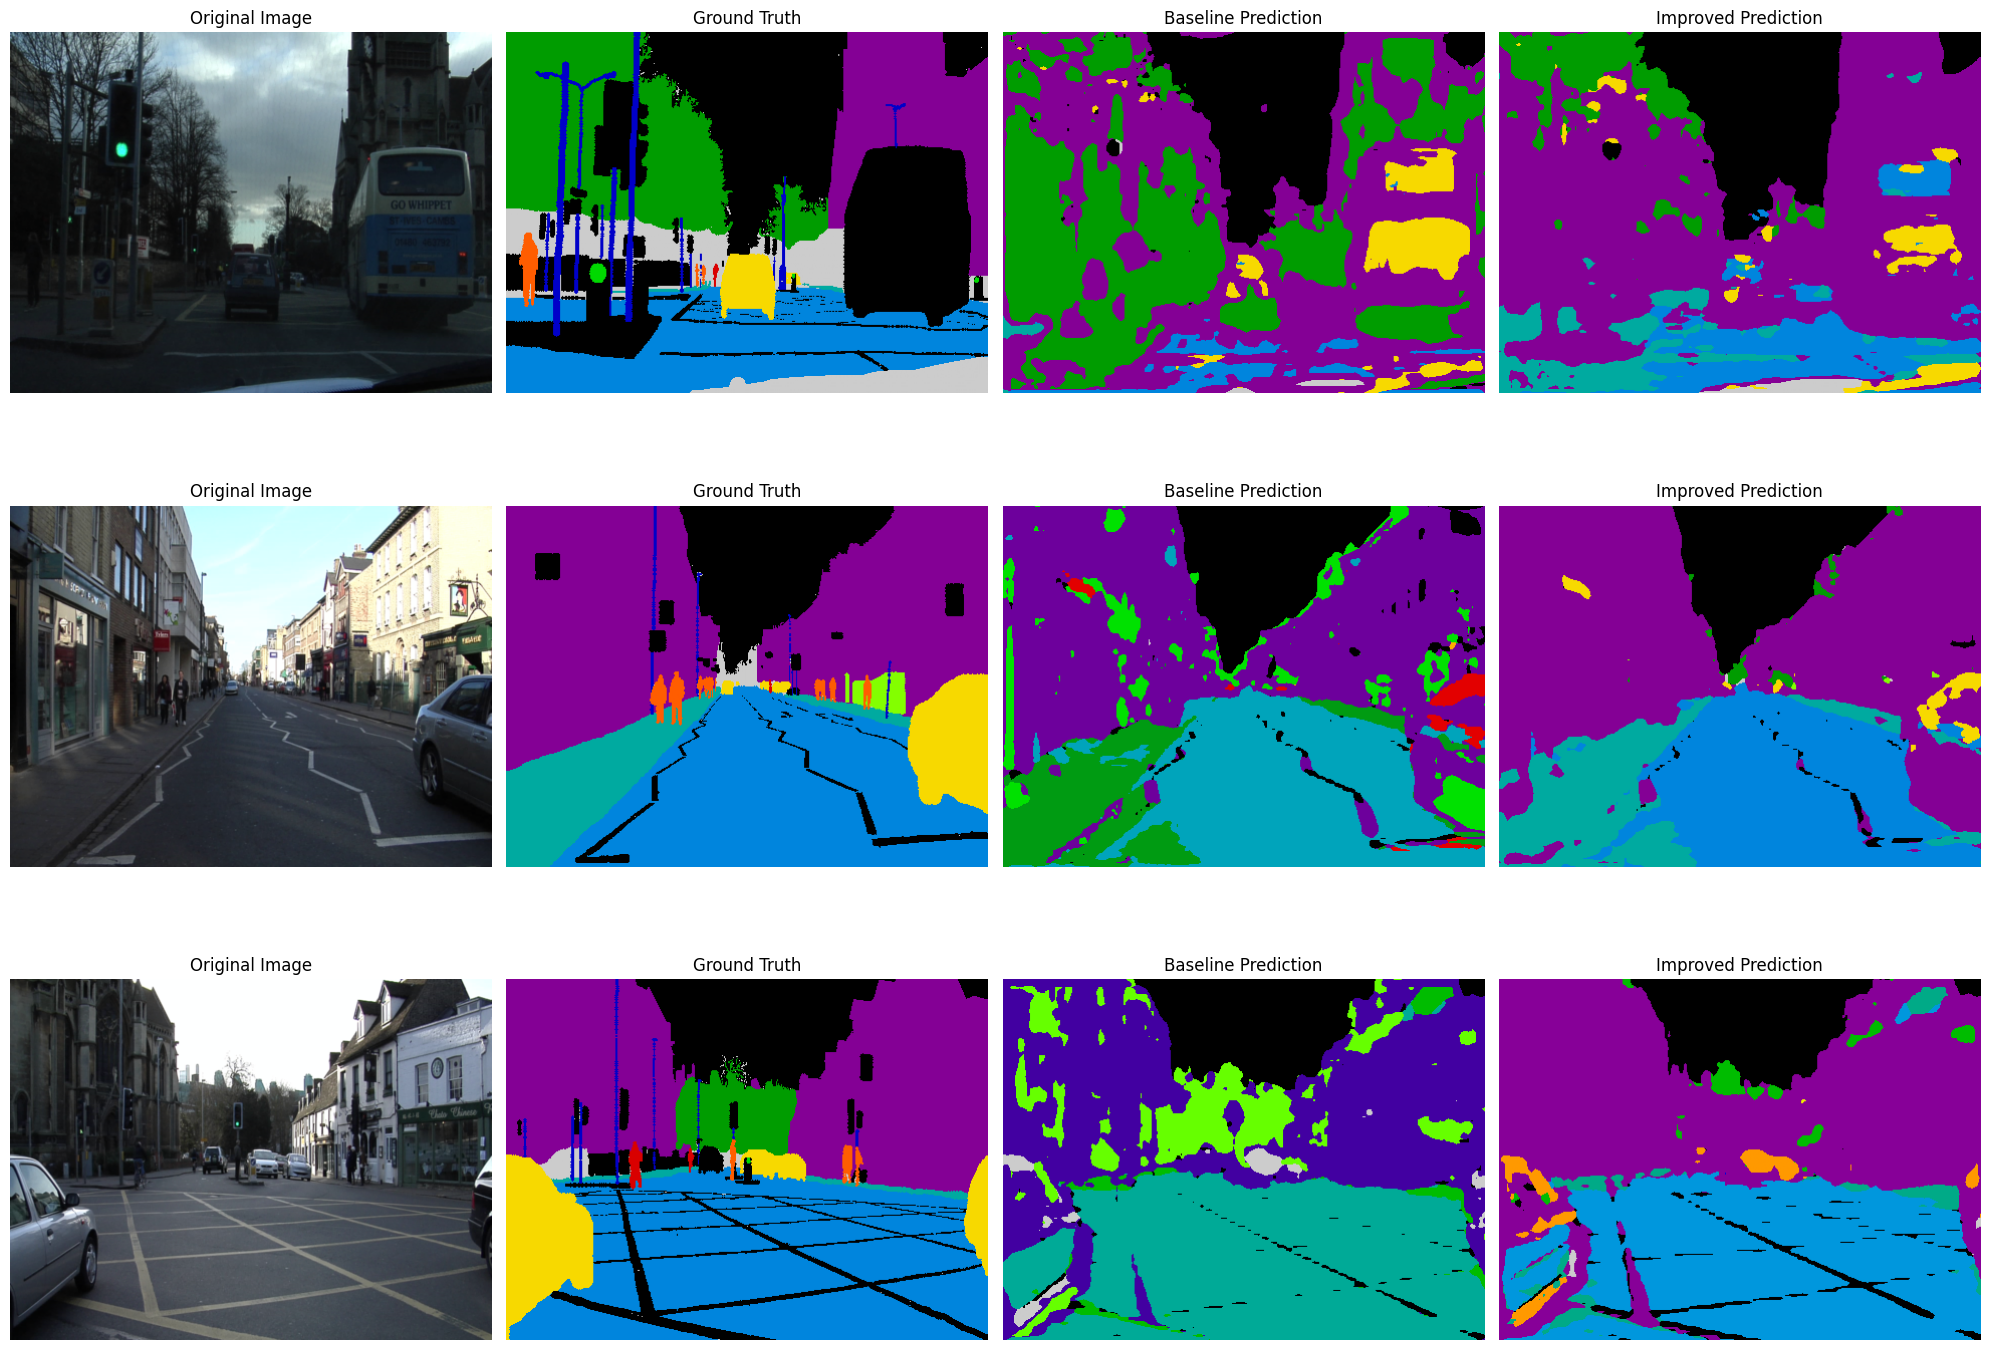

In [24]:
visualize_baseline_vs_improved(
    model_base,
    model_imp,
    test_ds,
    device,
    num_samples=3
)


_______________

In [32]:
history_base = {
    'train_loss': [
        1.3525, 1.1153, 1.0875, 1.0367, 1.0205,
        0.9785, 0.9683, 0.9684, 0.9354, 0.9219,
        0.8950, 0.8851, 0.8851, 0.8733, 0.8755
    ],
    'val_miou': [
        0.1614, 0.1616, 0.1904, 0.1706, 0.1952,
        0.1921, 0.1918, 0.2124, 0.2210, 0.2364,
        0.2348, 0.2145, 0.2185, 0.2184, 0.2377
    ]
}


In [33]:
history_imp = {
    'train_loss': [
        1.3078, 1.0091, 0.9602, 0.9135, 0.8763,
        0.8511, 0.8220, 0.8182, 0.7884, 0.7733,
        0.7679, 0.7508, 0.7284, 0.7195, 0.7158
    ],
    'val_miou': [
        0.1657, 0.2047, 0.2171, 0.2328, 0.2342,
        0.2390, 0.2345, 0.2467, 0.2502, 0.2760,
        0.2766, 0.2642, 0.2737, 0.2742, 0.2735
    ]
}


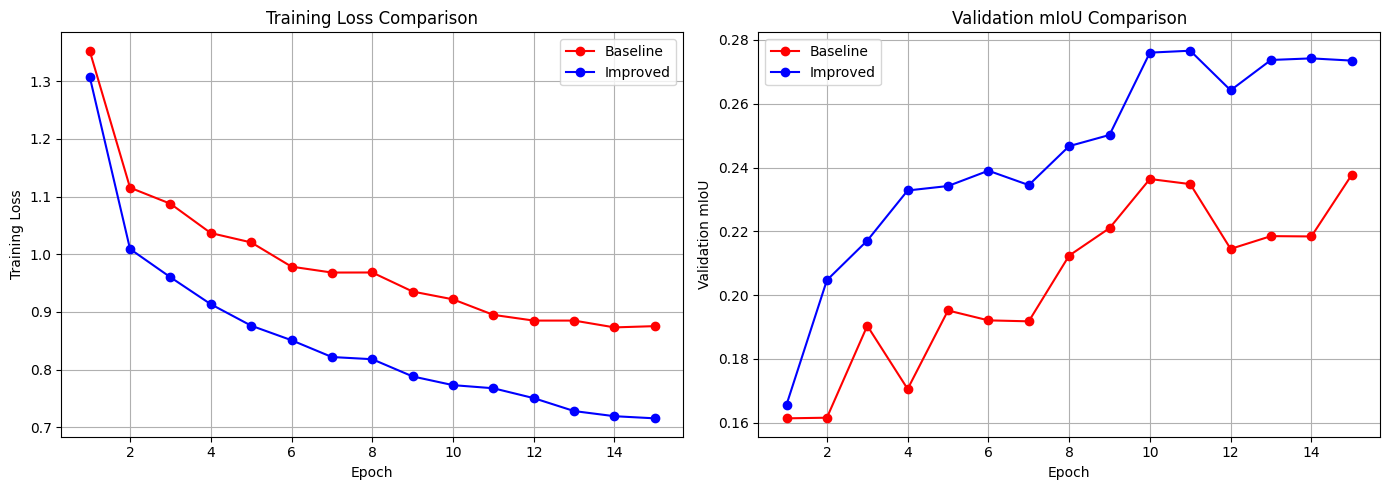

In [34]:
import matplotlib.pyplot as plt

epochs = range(1, 16)

plt.figure(figsize=(14, 5))

# ---- Training Loss ----
plt.subplot(1, 2, 1)
plt.plot(epochs, history_base['train_loss'], 'r-o', label='Baseline')
plt.plot(epochs, history_imp['train_loss'], 'b-o', label='Improved')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)

# ---- Validation mIoU ----
plt.subplot(1, 2, 2)
plt.plot(epochs, history_base['val_miou'], 'r-o', label='Baseline')
plt.plot(epochs, history_imp['val_miou'], 'b-o', label='Improved')
plt.xlabel('Epoch')
plt.ylabel('Validation mIoU')
plt.title('Validation mIoU Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('baseline_vs_improved_metrics.png', dpi=300)
plt.show()
